# 11. BERT — Masked Language Model

**Цель:** Реализовать BERT-подобную модель (Encoder-only), обучить на задаче Masked Language Model (MLM), визуализировать контекстуальные представления.

---

In [1]:
# Маскировка 80/10/10: 80% [MASK], 10% случайный, 10% без изменений.
# Почему не 100% [MASK]? Модель учится только паттернам [MASK], не обобщает.
import sys, os, logging, math
LOG_LEVEL = os.getenv("LOG_LEVEL", "DEBUG")
logging.basicConfig(level=getattr(logging, LOG_LEVEL), format="%(asctime)s [%(levelname)s] %(name)s: %(message)s", stream=sys.stderr)
log = logging.getLogger("bert")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)

2026-06-01 00:51:00,931 [DEBUG] matplotlib: matplotlib data path: /Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data


2026-06-01 00:51:00,938 [DEBUG] matplotlib: CONFIGDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:51:00,942 [DEBUG] matplotlib: interactive is False


2026-06-01 00:51:00,943 [DEBUG] matplotlib: platform is darwin


2026-06-01 00:51:00,971 [DEBUG] matplotlib: CACHEDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:51:00,973 [DEBUG] matplotlib.font_manager: Using fontManager instance from /Users/demanbudaev/.matplotlib/fontlist-v390.json


2026-06-01 00:51:01,099 [INFO] bert: Используем устройство: mps


## 11.1 Специальные токены BERT

| Токен | ID | Назначение |
|-------|----|------------|
| [PAD] | 0  | Выравнивание длин |
| [CLS] | 1  | Классификационный токен (начало) |
| [SEP] | 2  | Разделитель предложений |
| [MASK]| 3  | Маскированный токен |
| [UNK] | 4  | Неизвестный токен |

In [2]:
# Специальные токены: [CLS] для классификации, [SEP] для разделения.
PAD, CLS, SEP, MASK, UNK = 0, 1, 2, 3, 4
log.debug("Special tokens defined: PAD=%d, CLS=%d, SEP=%d, MASK=%d, UNK=%d", PAD, CLS, SEP, MASK, UNK)

2026-06-01 00:51:01,102 [DEBUG] bert: Special tokens defined: PAD=0, CLS=1, SEP=2, MASK=3, UNK=4


## 11.2 BERT-архитектура (Encoder-only)

BERT — это стопка энкодерных блоков трансформера с bidirectionnal self-attention (в отличие от GPT, где attention каузальный).

## BERT: почему encoder-only (а не decoder) для понимания

BERT использует MLM (Masked Language Model) — двунаправленный контекст, где модель видит
все токены одновременно. Это принципиально отличается от CLM (Causal Language Model) в GPT,
где внимание каузальное (unidirectional).

| Характеристика | BERT (Encoder) | GPT (Decoder) |
|---|---|---|
| Pre-training | MLM — маскировка 15% токенов | CLM — предсказание следующего токена |
| Attention | Bidirectional (оба направления) | Unidirectional (только влево) |
| Контекст | Полный контекст с обеих сторон | Только левый контекст |
| Задачи | Понимание (NLI, QA, классификация) | Генерация (text completion, chat) |

Для задач **понимания** (NLP understanding) — таких как классификация, NER, QA —
необходим доступ к полному контексту. Encoder-only архитектура BERT позволяет модели
видеть все токены последовательности одновременно, что критически важно для понимания смысла.

> **Ссылка:** Devlin et al., 2018 — *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*


In [3]:
# BERT — только энкодер: полный двунаправленный контекст нужен для задач понимания.
# Нижние слои улавливают поверхностные паттерны; верхние — семантический смысл.
log.debug("Implementing BERT model")

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, Q, K, V, mask=None):
        batch = Q.size(0)
        n_heads = self.W_O.out_features // self.d_k
        Q = self.W_Q(Q).view(batch, -1, n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch, -1, n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch, -1, n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(1).unsqueeze(2) == 0, float('-inf'))
        attn = self.dropout(F.softmax(scores, dim=-1))
        output = torch.matmul(attn, V).transpose(1, 2).contiguous().view(batch, -1, self.W_O.out_features)
        return self.W_O(output)

class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 4 * d_model)
        self.fc2 = nn.Linear(4 * d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        x = x + self.dropout1(self.attention(self.norm1(x), self.norm1(x), self.norm1(x), mask))
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        return x

class BERT(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, num_layers=4, max_len=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
        self.dropout_pe = nn.Dropout(dropout)
        
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, n_heads, dropout) for _ in range(num_layers)
        ])
        
        # MLM голова (Masked Language Model)
# Линейная проекция из d_model в vocab_size предсказывает ID маскированных токенов.
        self.mlm_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, vocab_size),
        )
        
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        
        log.info("BERT: vocab=%d, d_model=%d, n_heads=%d, layers=%d, params=%d",
                 vocab_size, d_model, n_heads, num_layers, sum(p.numel() for p in self.parameters()))
    
    def forward(self, x, mask=None):
        x = self.dropout_pe(self.embedding(x) * math.sqrt(self.d_model) + self.pe[:, :x.size(1), :])
        for layer in self.layers:
            x = layer(x, mask)
        return self.mlm_head(x)  # (batch, seq_len, vocab)

2026-06-01 00:51:01,114 [DEBUG] bert: Implementing BERT model


## 11.3 Masked Language Model: маскировка 15% токенов

**Стратегия маскировки (BERT原文):**
- 80% → заменить на [MASK]
- 10% → заменить на случайный токен
- 10% → оставить как есть

## 80/10/10 стратегия маскировки: почему не 100%

В оригинальной статье BERT используется **80/10/10** стратегия для masked tokens:
- **80%** — заменить на `[MASK]`
- **10%** — заменить на случайный токен из словаря
- **10%** — оставить как есть (исходный токен)

### Проблема 100% маскировки

Если всегда заменять выбранные токены на `[MASK]`, модель научится предсказывать
только токены `[MASK]`. Но на этапе fine-tuning токен `[MASK]` **никогда не встречается** —
возникает mismatch между pre-training и fine-tuning.

### Как 80/10/10 решает проблему

- **10% случайных токенов** — модель учится исправлять ошибки, не полагаясь на наличие `[MASK]`.
- **10% неизменённых** — модель учится сохранять исходный токен и понимать, что токен НЕ был заменён.

Этот трюк заставляет модель строить **осмысленные контекстуальные представления**, а не просто
детектировать наличие `[MASK]`.

> **Ссылка:** Devlin et al., 2018 — Section 3.3.1


In [4]:
# 80/10/10 смягчает несоответствие pre-train/fine-tune: модель видит и не-[MASK] токены.
log.debug("Implementing MLM masking function")

def mask_tokens(input_ids, vocab_size, mask_prob=0.15, special_tokens=(PAD, CLS, SEP)):
    """Маскировка токнов для MLM."""
    labels = input_ids.clone()
    
    # Не маскируем специальные токены
    special_mask = torch.zeros_like(input_ids, dtype=torch.bool)
    for tok in special_tokens:
        special_mask = special_mask | (input_ids == tok)
    
    probability = torch.full(input_ids.shape, mask_prob, device=input_ids.device)
    masked = torch.bernoulli(probability).bool()
    masked = masked & ~special_mask.to(input_ids.device)  # не трогаем специальные токены
    
    # 80% -> [MASK]
    mask_replace = torch.bernoulli(torch.full(input_ids.shape, 0.8, device=input_ids.device)).bool() & masked
    input_ids[mask_replace] = MASK
    
    # 10% -> случайный токен
    random_replace = torch.bernoulli(torch.full(input_ids.shape, 0.5, device=input_ids.device)).bool() & masked & ~mask_replace
    random_tokens = torch.randint(5, vocab_size, input_ids.shape, device=input_ids.device)
    input_ids[random_replace] = random_tokens[random_replace]
    
    # 10% -> без изменений (labels already set)
    
    # Labels: -100 для позиций, где loss не считаем
    labels[~masked] = -100
    
    return input_ids, labels

# Демонстрация
example = torch.tensor([[CLS, 5, 12, 8, 3, 15, SEP, PAD, PAD]])
masked, labels = mask_tokens(example.clone(), vocab_size=20)
print(f"Original: {example[0].tolist()}")
print(f"Masked:   {masked[0].tolist()}")
print(f"Labels:   {labels[0].tolist()}")
log.info("MLM masking demonstration complete")

2026-06-01 00:51:01,119 [DEBUG] bert: Implementing MLM masking function


2026-06-01 00:51:01,121 [INFO] bert: MLM masking demonstration complete


Original: [1, 5, 12, 8, 3, 15, 2, 0, 0]
Masked:   [1, 5, 12, 8, 3, 15, 2, 0, 0]
Labels:   [-100, -100, -100, -100, -100, -100, -100, -100, -100]


## 11.4 Подготовка данных и обучение BERT

In [5]:
# MLM голова: linear d_model -> vocab_size, loss CE только на маскированных позициях.
log.info("Preparing MLM training data")

vocab_size = 30
max_len = 12

def make_mlm_data(num_samples):
    data = []
    for _ in range(num_samples):
        length = np.random.randint(3, max_len - 1)
        seq = [CLS] + np.random.randint(5, vocab_size, size=length).tolist() + [SEP]
        seq = seq + [PAD] * (max_len - len(seq))
        data.append(seq)
    return torch.tensor(data)

train_data = make_mlm_data(2000)
val_data = make_mlm_data(500)

bert = BERT(vocab_size=vocab_size, d_model=32, n_heads=4, num_layers=4, max_len=max_len).to(device)
optimizer = torch.optim.AdamW(bert.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

print(f"Train samples: {len(train_data)}, Val samples: {len(val_data)}")
print(f"BERT params: {sum(p.numel() for p in bert.parameters()):,}")

2026-06-01 00:51:01,125 [INFO] bert: Preparing MLM training data


2026-06-01 00:51:01,158 [INFO] bert: BERT: vocab=30, d_model=32, n_heads=4, layers=4, params=53374


Train samples: 2000, Val samples: 500
BERT params: 53,374


2026-06-01 00:51:01,717 [INFO] bert: Starting BERT MLM training


2026-06-01 00:51:03,606 [INFO] bert: Epoch 0: train=3.5137, val=3.3308


2026-06-01 00:51:09,205 [INFO] bert: Epoch 10: train=3.1534, val=3.1432


2026-06-01 00:51:14,617 [INFO] bert: Epoch 20: train=3.1280, val=3.1463


2026-06-01 00:51:20,133 [INFO] bert: Epoch 30: train=3.1261, val=3.0970


...

2026-06-01 00:51:25,281 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansBuhid-Regular.ttf', name='Noto Sans Buhid', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:51:25,281 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Phosphate.ttc', name='Phosphate', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:51:25,282 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansInscriptionalParthian-Regular.ttf', name='Noto Sans Inscriptional Parthian', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:51:25,282 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/STIXNonUni.otf', name='STIXNonUnicode', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:51:25,282 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0 to DejaVu Sans ('/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf') with score of 0.050000.


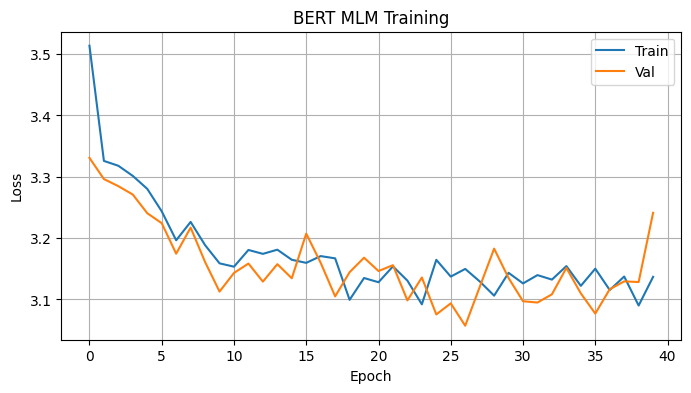

2026-06-01 00:51:25,340 [INFO] bert: BERT training complete, best val loss=3.0571


In [6]:
# Только энкодер: двунаправленный attention даёт богатый контекст для MLM.
log.info("Starting BERT MLM training")

n_epochs = 40
batch_size = 64
best_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    bert.train()
    epoch_loss = 0
    perm = torch.randperm(len(train_data))
    
    for i in range(0, len(train_data), batch_size):
        idx = perm[i:i+batch_size]
        batch = train_data[idx].clone().to(device)
        masked, labels = mask_tokens(batch, vocab_size)
        
        output = bert(masked)
        loss = criterion(output.reshape(-1, vocab_size), labels.reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Валидация
    bert.eval()
    val_loss = 0
    with torch.no_grad():
        for i in range(0, len(val_data), batch_size):
            batch = val_data[i:i+batch_size].clone().to(device)
            masked, labels = mask_tokens(batch, vocab_size)
            output = bert(masked)
            val_loss += criterion(output.reshape(-1, vocab_size), labels.reshape(-1)).item()
    
    avg_train = epoch_loss / (len(train_data) / batch_size)
    avg_val = val_loss / (len(val_data) / batch_size)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    
    if epoch % 10 == 0:
        log.info("Epoch %d: train=%.4f, val=%.4f", epoch, avg_train, avg_val)
    
    if avg_val < best_loss:
        best_loss = avg_val

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BERT MLM Training')
plt.grid(True)
plt.show()
log.info("BERT training complete, best val loss=%.4f", best_loss)

## 11.5 Демонстрация: предсказание замаскированных токенов

In [7]:
# Контекстуальные эмбеддинги: мелкие слои кодируют синтаксис; глубокие — семантику.
log.debug("Predicting masked tokens")

@torch.no_grad()
def predict_masked(model, input_ids):
    model.eval()
    output = model(input_ids.to(device))
    probs = F.softmax(output, dim=-1)
    preds = output.argmax(-1)
    return preds, probs

# Создаём пример с [MASK]
example = torch.tensor([[CLS, 12, 7, MASK, 19, 5, SEP, PAD, PAD, PAD, PAD, PAD]])
preds, probs = predict_masked(bert, example)

# Показываем предсказание для маскированной позиции
mask_pos = (example == MASK).nonzero()[0, 1].item()
mask_probs = probs[0, mask_pos]
top5 = mask_probs.argsort(descending=True)[:5]

print(f"Input: {example[0].tolist()}")
print(f"Prediction at position {mask_pos}:")
for tok in top5:
    print(f"  Token {tok.item():2d}: {mask_probs[tok].item():.2%}")
log.info("MLM prediction demo complete")

2026-06-01 00:51:25,345 [DEBUG] bert: Predicting masked tokens


2026-06-01 00:51:25,640 [INFO] bert: MLM prediction demo complete


Input: [1, 12, 7, 3, 19, 5, 2, 0, 0, 0, 0, 0]
Prediction at position 3:
  Token  9: 5.30%
  Token 18: 4.71%
  Token  7: 4.67%
  Token 28: 4.60%
  Token 10: 4.56%


## 11.6 Контекстуальные представления разных слоёв

Извлечём эмбеддинги из разных слоёв и покажем, как они меняются.

2026-06-01 00:51:25,647 [DEBUG] bert: Extracting contextual embeddings from all layers


2026-06-01 00:51:25,650 [INFO] bert: BERT: vocab=30, d_model=32, n_heads=4, layers=4, params=53374


2026-06-01 00:51:25,708 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x1159deb20>


2026-06-01 00:51:25,715 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x115a3f5e0>


2026-06-01 00:51:25,722 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x115a7ed00>


2026-06-01 00:51:25,729 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x115ac87f0>


2026-06-01 00:51:25,735 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x115b11220>


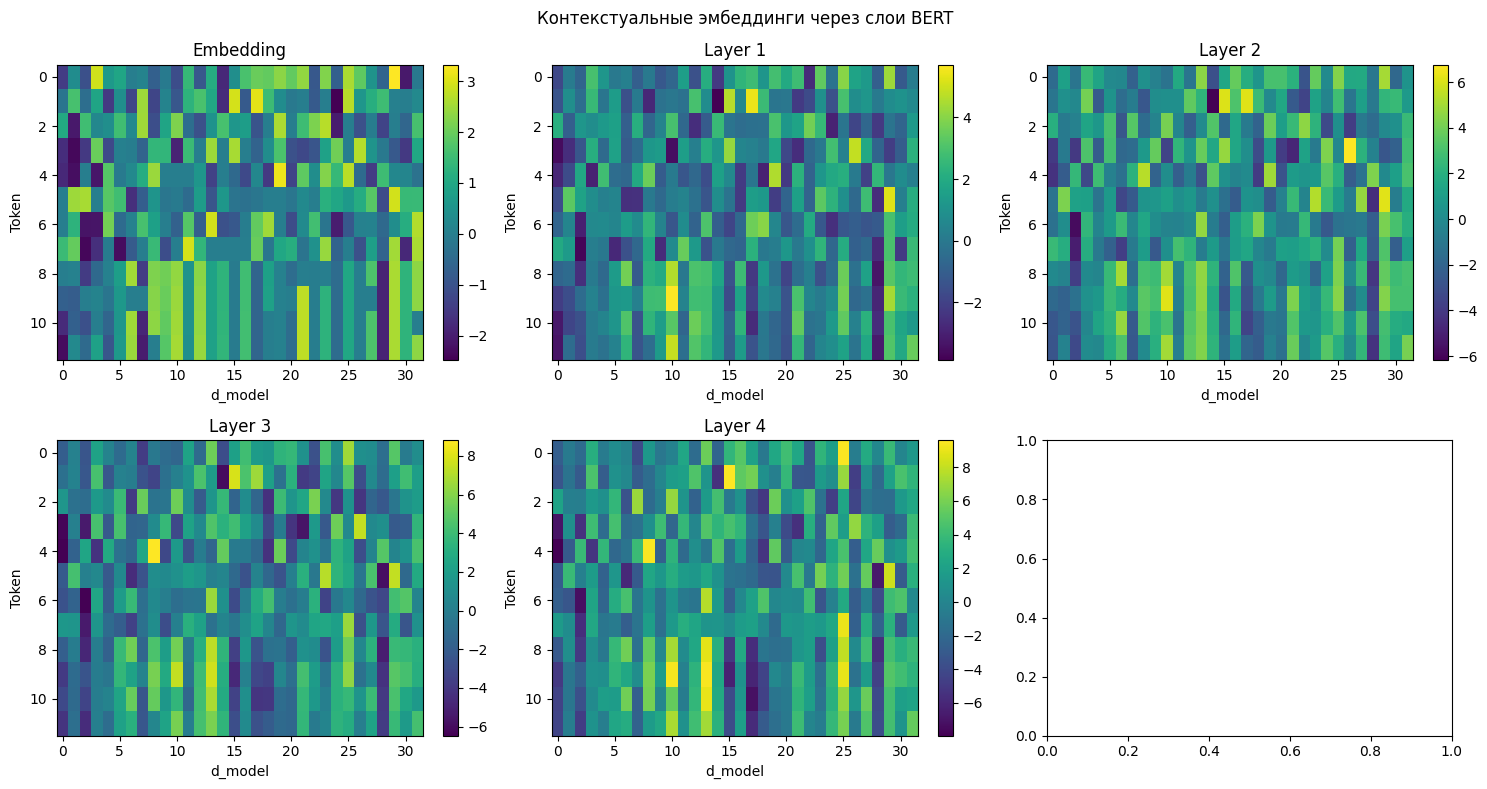

2026-06-01 00:51:26,057 [INFO] bert: Contextual embedding visualization complete


In [8]:
log.debug("Extracting contextual embeddings from all layers")
# Нижние слои: локальные текстовые паттерны. Верхние слои: глобальный смысл.

class BERTWithHooks(BERT):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.layer_outputs = []
    
    def forward(self, x, mask=None):
        self.layer_outputs = []
        x = self.dropout_pe(self.embedding(x) * math.sqrt(self.d_model) + self.pe[:, :x.size(1), :])
        self.layer_outputs.append(x.detach())
        for layer in self.layers:
            x = layer(x, mask)
            self.layer_outputs.append(x.detach())
        return self.mlm_head(x)

bert_hooks = BERTWithHooks(vocab_size=vocab_size, d_model=32, n_heads=4, num_layers=4, max_len=max_len).to(device)
bert_hooks.load_state_dict(bert.state_dict())

test_seq = torch.tensor([[CLS, 10, 15, 8, 12, 6, 18, SEP, PAD, PAD, PAD, PAD]])
with torch.no_grad():
    bert_hooks(test_seq.to(device))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    if i < len(bert_hooks.layer_outputs):
        im = ax.imshow(bert_hooks.layer_outputs[i][0].cpu().numpy(), cmap='viridis', aspect='auto')
        ax.set_title(f'Layer {i}' if i > 0 else 'Embedding')
        ax.set_xlabel('d_model')
        ax.set_ylabel('Token')
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Контекстуальные эмбеддинги через слои BERT')
plt.tight_layout()
plt.show()
log.info("Contextual embedding visualization complete")

In [9]:
# Архитектура BERT encoder-only учит двунаправленные представления через MLM.
print("=== BERT (Masked Language Model) complete ===")
print("Topics covered:")
print("  - Special tokens: [CLS], [SEP], [MASK], [PAD]")
print("  - BERT architecture (Encoder-only)")
print("  - MLM masking strategy (80/10/10)")
print("  - BERT MLM training loop")
print("  - Predicting masked tokens")
print("  - Contextual embeddings through layers")
print(f"  - Best MLM loss: {best_loss:.4f}")
log.info("BERT notebook complete")

2026-06-01 00:51:26,063 [INFO] bert: BERT notebook complete


=== BERT (Masked Language Model) complete ===
Topics covered:
  - Special tokens: [CLS], [SEP], [MASK], [PAD]
  - BERT architecture (Encoder-only)
  - MLM masking strategy (80/10/10)
  - BERT MLM training loop
  - Predicting masked tokens
  - Contextual embeddings through layers
  - Best MLM loss: 3.0571


## Полезные ссылки

- **BERT paper:** Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. arXiv:1810.04805.
  - [arXiv](https://arxiv.org/abs/1810.04805)
- **MLM Objective:** Section 3.1 — Masked Language Model.
- **80/10/10 Strategy:** Section 3.3.1 — Masking details.
- **Contextual Representations:** Layer-wise analysis in Section 5.4 and Appendix C.
